In [1]:
import sys
from functools import partial
import numpy as np
import matplotlib.pyplot as plt



In [2]:
class DataProxy(object):
    """An empty object to attach fields to it. With a simple instance of
    object() this is impossible but doable with an empty class."""

    def __repr__(self):
        return "DataProxy object for '{0}'".format(self.alias)


def makeDummyData():
    nx, ny = 1920, 1200
    yRange = -1, 2

    data = DataProxy()
    data.alias = 'dummy data'
    data.x = np.arange(nx)
    data.y = np.linspace(*yRange, ny)
    xv, yv = np.meshgrid(data.x, data.y)
    # print('x', xv.shape, 'y', yv.shape)
    signal = np.exp(-((xv-nx/3)**2/(nx*0.2)**2 + yv**2/0.15**2))
    signal += 0.5*np.exp(-((xv-2*nx/3)**2/(nx*0.2)**2 + (yv-1)**2/0.15**2))
    noise = 0.7 * np.random.random(size=signal.shape)
    data.xes2D = (signal + noise) * 100
    # print('2D', data.xes2D.shape)
    data.xes1D_left = np.zeros(ny)
    # data.xes1D_bottom = np.zeros(nx)
    return data


(nx, ny)=(1920, 1200)


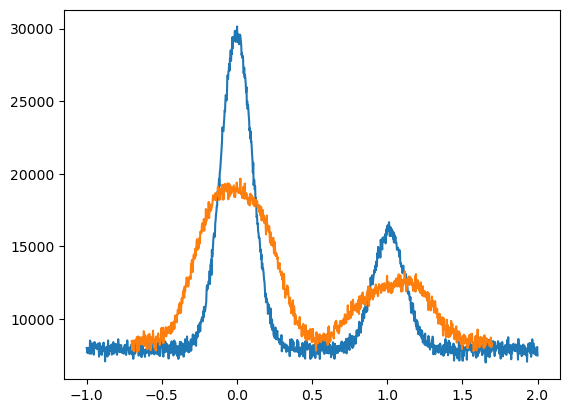

In [4]:
def test():
    data_ = makeDummyData()
    proj = data_.xes2D
    # plt.imshow(proj)
    # plt.show()
    yRange = -1, 2

    ny, nx = proj.shape
    print(f"{(nx, ny)=}")
    data_x = np.arange(nx)
    data_y = np.linspace(*yRange, ny)

    useFractionalPixels=True

    begin=(500, -0.5)
    end=(1250, 1.5)
    width=0.6

    x1, y1 = begin
    x2, y2 = end
    w = width
    try:
        k = (y2 - y1) / (x2 - x1)
        b = y2 - k*x2
    except ZeroDivisionError:
        k, b =  np.inf, 0
    dataCut = np.array(proj, dtype=np.float32)
    u, v = np.meshgrid(data_x, data_y)
    if len(data_y) > 1:
        dt = abs(data_y[-1]-data_y[0]) / (len(data_y)-1)
    else:
        dt = 1
    vm = v - k*u - b - w/2
    vp = v - k*u - b + w/2
    if useFractionalPixels and (dt > 0):
        dataCut[vm > dt] = 0
        dataCut[vp < -dt] = 0
        vmWherePartial = (vm > 0) & (vm < dt)
        dataCut[vmWherePartial] *= vm[vmWherePartial] / dt
        vpWherePartial = (vp > -dt) & (vp < 0)
        dataCut[vpWherePartial] *= -vp[vpWherePartial] / dt
    else:
        dataCut[vm > 0] = 0
        dataCut[vp < 0] = 0
    proj_left = dataCut.sum(axis=1)

    proj_bottom = dataCut.sum(axis=0)
    x_bottom = k*data_x + b

    # cutting of the incomplete ends:
    gd = (x_bottom - w/2 > data_y[0]) & (x_bottom + w/2 < data_y[-1])
    proj_bottom[~gd] = np.nan
    # proj_bottom = proj_bottom[gd]
    # x_bottom = x_bottom[gd]

    plt.plot(data_y, proj_left)
    plt.plot(x_bottom, proj_bottom)

test()